# MODEL 03 — ensembles (Random Forest + Gradient Boosting), walk-forward tuning

Tree ensembles are the second family of models, chosen because they capture **nonlinearities and
interactions** (e.g. star-in-small-market, role-player-in-big-market) that a linear model cannot.
Two estimators are tuned and compared:

- **Random Forest** (`RandomForestRegressor`)
- **Gradient Boosting** (`GradientBoostingRegressor`)

### Walk-forward tuning (the key protocol)

`val` / `test` must never influence tuning. Hyperparameters are therefore selected with
**expanding-window walk-forward CV on train years only** — each fold fits on the past and scores
the next year, exactly how a real deployment would have to operate:

| fold | fit years ≤ | eval year | fit rows | eval rows |
|---|---:|---:|---:|---:|
| 1 | 2016 | 2017 | 272 | 101 |
| 2 | 2017 | 2018 | 373 | 73 |
| 3 | 2018 | 2019 | 446 | 129 |
| 4 | 2019 | 2020 | 575 | 93 |
| 5 | 2020 | 2021 | 668 | 115 |

A **linear reference** (`ElasticNetCV`, the MODEL 02 final estimator) is scored on the same folds
so the trees must beat it under an *identical* protocol. Final models are then refit on all of
train (`RandomizedSearchCV(refit=True)`) and evaluated on the untouched `val` (headline) and
`test` (hold-out).

Features: `controls` + `chosen_stats` from `data/model/linear_features.json` = **controls + chosen_stats**
(same canonical set as the final linear model).

Outputs: `data/model/results.csv` (appended), `data/model/predictions_ensemble.csv`.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNetCV
from sklearn.inspection import permutation_importance, partial_dependence

PROJECT_ROOT = Path("..")
PREP_CSV = PROJECT_ROOT / "data" / "model" / "prep.csv"
RESULTS_CSV = PROJECT_ROOT / "data" / "model" / "results.csv"
PRED_CSV = PROJECT_ROOT / "data" / "model" / "predictions_ensemble.csv"
FEATURES_JSON = PROJECT_ROOT / "data" / "model" / "linear_features.json"

prep = pd.read_csv(PREP_CSV)
TARGET = "log_aav_cap_share"
y = prep[TARGET]
masks = {s: prep["split"].eq(s) for s in ("train", "val", "test")}

feat_meta = json.load(open(FEATURES_JSON))
FEATS = feat_meta["controls"] + feat_meta["chosen_stats"]
print("features:", len(FEATS), "=", len(feat_meta["controls"]), "controls +",
      len(feat_meta["chosen_stats"]), "stats")

X_train = prep.loc[masks["train"], FEATS].reset_index(drop=True)
y_train = y[masks["train"]].reset_index(drop=True)
print("split sizes:", {s: int(m.sum()) for s, m in masks.items()})

features: 60 = 36 controls + 24 stats
split sizes: {'train': 906, 'val': 216, 'test': 242}


## 1. Walk-forward splitter

`WalkForwardSplit` masks on `deal_year`: fold *k* fits on `deal_year ≤ cut` and scores
`deal_year == eval`. It is passed directly to `RandomizedSearchCV` as `cv`, so every candidate
hyperparameter set is judged purely on its one-year-ahead performance.

In [2]:
train_years = prep.loc[masks["train"], "deal_year"].to_numpy()
FOLD_DEFS = [(2016, 2017), (2017, 2018), (2018, 2019), (2019, 2020), (2020, 2021)]


class WalkForwardSplit:
    def __init__(self, years, fold_defs):
        self.folds = [(np.where(years <= c)[0], np.where(years == e)[0]) for c, e in fold_defs]

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.folds)

    def split(self, X, y=None, groups=None):
        for tr, va in self.folds:
            yield tr, va


wf = WalkForwardSplit(train_years, FOLD_DEFS)
print("walk-forward folds:")
for i, (c, e) in enumerate(FOLD_DEFS, 1):
    tr, va = wf.folds[i - 1]
    print(f"  fold {i}: fit {len(tr):3d} rows (<= {c}), eval {len(va):3d} rows ({e})")

walk-forward folds:
  fold 1: fit 395 rows (<= 2016), eval 101 rows (2017)
  fold 2: fit 496 rows (<= 2017), eval  73 rows (2018)
  fold 3: fit 569 rows (<= 2018), eval 129 rows (2019)
  fold 4: fit 698 rows (<= 2019), eval  93 rows (2020)
  fold 5: fit 791 rows (<= 2020), eval 115 rows (2021)


## 2. Linear reference on the same folds

The MODEL 02 final estimator (`ElasticNetCV`, standardized, alpha × l1_ratio grid) is refit on
each walk-forward fold and scored on the eval year. Inside each fold the alpha penalty is
selected by a nested expanding-window walk-forward over that fold's own train years, so
the linear reference never mixes future years into penalty tuning. This is the bar the trees must clear under an
**identical** protocol — it also guards against the trees simply winning because the linear model
was tuned on a different window.

In [3]:
from metrics import rmse


ALPHA_GRID = np.logspace(-3, 1, 18)
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

def _expanding_nested(tr, min_eval=5):
    # Year-ordered nested folds for alpha selection, restricted to the current
    # outer fold's train rows so penalty selection never mixes future years in.
    tr_sorted = np.sort(tr)
    sub_years = train_years[tr_sorted]
    uniq = np.unique(sub_years)
    folds = []
    for i in range(1, len(uniq)):
        fit_pos = np.where(sub_years <= uniq[i - 1])[0]
        eval_pos = np.where(sub_years == uniq[i])[0]
        if len(eval_pos) >= min_eval:
            folds.append((fit_pos, eval_pos))
    return folds


linear_fold_rmse = []
for tr, va in wf.folds:
    nested = _expanding_nested(tr)  # walk-forward folds over the fold's own train years
    pipe = make_pipeline(
        StandardScaler(),
        ElasticNetCV(l1_ratio=L1_RATIOS, alphas=ALPHA_GRID, cv=list(nested),
                     max_iter=50000, tol=1e-4, n_jobs=-1, random_state=0),
    )
    pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
    linear_fold_rmse.append(rmse(y_train.iloc[va], pipe.predict(X_train.iloc[va])))

print("linear (ElasticNet) walk-forward RMSE per fold:")
for i, r in enumerate(linear_fold_rmse, 1):
    print(f"  fold {i}: {r:.4f}")
print(f"  mean: {np.mean(linear_fold_rmse):.4f}")

linear (ElasticNet) walk-forward RMSE per fold:
  fold 1: 0.5034
  fold 2: 0.4729
  fold 3: 0.5210
  fold 4: 0.7775
  fold 5: 0.4117
  mean: 0.5373


## 3. Model A — Random Forest (walk-forward tuned)

`RandomizedSearchCV` over `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`,
scoring **neg RMSE on the log target** across the 5 walk-forward folds. `refit=True` re-fits the
best config on the full 783 train rows, so `best_estimator_` is the final RF.

In [4]:
from metrics import evaluate, rmse, mae, r2


results = []


def register(model, description, fit_params, pred_series):
    for split, m in masks.items():
        row = {"model": model, "description": description, "fit_params": fit_params,
               "split": split}
        row.update(evaluate(y[m], pred_series[m]))
        results.append(row)
    return pred_series


RF_GRID = {
    "n_estimators": [400, 700, 1000],
    "max_depth": [None, 5, 8, 12],
    "min_samples_leaf": [2, 4, 8],
    "max_features": ["sqrt", 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=0, n_jobs=-1),
    RF_GRID, n_iter=40, cv=wf, scoring="neg_root_mean_squared_error",
    random_state=0, refit=True, n_jobs=-1,
)
rf_search.fit(X_train, y_train)

cv_ = rf_search.cv_results_
bi = int(rf_search.best_index_)
rf_fold_rmse = [-float(cv_[f"split{k}_test_score"][bi]) for k in range(5)]
print("RF best params:", rf_search.best_params_)
print("RF walk-forward fold RMSE:", [round(r, 4) for r in rf_fold_rmse])
print(f"RF walk-forward mean RMSE: {np.mean(rf_fold_rmse):.4f}   (linear ref: {np.mean(linear_fold_rmse):.4f})")

RF best params: {'n_estimators': 700, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': None}
RF walk-forward fold RMSE: [0.4584, 0.4003, 0.4445, 0.439, 0.3309]
RF walk-forward mean RMSE: 0.4146   (linear ref: 0.5373)


## 4. Model B — Gradient Boosting (walk-forward tuned)

Same protocol, over `n_estimators`, `learning_rate`, `max_depth`, `min_samples_leaf`,
`subsample`.

In [5]:
GB_GRID = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.02, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 20],
    "subsample": [0.8, 1.0],
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=0),
    GB_GRID, n_iter=40, cv=wf, scoring="neg_root_mean_squared_error",
    random_state=0, refit=True, n_jobs=-1,
)
gb_search.fit(X_train, y_train)

cv_ = gb_search.cv_results_
bi = int(gb_search.best_index_)
gb_fold_rmse = [-float(cv_[f"split{k}_test_score"][bi]) for k in range(5)]
print("GB best params:", gb_search.best_params_)
print("GB walk-forward fold RMSE:", [round(r, 4) for r in gb_fold_rmse])
print(f"GB walk-forward mean RMSE: {np.mean(gb_fold_rmse):.4f}   (linear ref: {np.mean(linear_fold_rmse):.4f})")

GB best params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 10, 'max_depth': 3, 'learning_rate': 0.02}
GB walk-forward fold RMSE: [0.4459, 0.4077, 0.4408, 0.4705, 0.3392]
GB walk-forward mean RMSE: 0.4208   (linear ref: 0.5373)


## 5. Tuning value check + final model registration

To prove the walk-forward tuning earns its keep, **untuned defaults** (`rf_default`,
`gb_default`) are also fit on train and scored on the walk-forward folds. Four models are then
registered into `results.csv` (fit on train, evaluated on val/test):

- `rf_default`, `gb_default` — defaults
- `rf_tuned`, `gb_tuned` — walk-forward-selected hyperparameters

In [6]:
rf_def = RandomForestRegressor(random_state=0, n_jobs=-1)
gb_def = GradientBoostingRegressor(random_state=0)

rf_def_fold, gb_def_fold = [], []
for tr, va in wf.folds:
    rf_def.fit(X_train.iloc[tr], y_train.iloc[tr])
    rf_def_fold.append(rmse(y_train.iloc[va], rf_def.predict(X_train.iloc[va])))
    gb_def.fit(X_train.iloc[tr], y_train.iloc[tr])
    gb_def_fold.append(rmse(y_train.iloc[va], gb_def.predict(X_train.iloc[va])))

wf_table = pd.DataFrame({
    "fold": [f"fold {i}" for i in range(1, 6)],
    "linear_ref": linear_fold_rmse,
    "rf_default": rf_def_fold,
    "gb_default": gb_def_fold,
    "rf_tuned": rf_fold_rmse,
    "gb_tuned": gb_fold_rmse,
})
wf_table.loc[len(wf_table)] = ["mean"] + [np.mean(wf_table[c]) for c in wf_table.columns[1:]]
print("walk-forward RMSE comparison:")
print(wf_table.round(4).to_string(index=False))

walk-forward RMSE comparison:
  fold  linear_ref  rf_default  gb_default  rf_tuned  gb_tuned
fold 1      0.5034      0.4673      0.4410    0.4584    0.4459
fold 2      0.4729      0.4307      0.4551    0.4003    0.4077
fold 3      0.5210      0.4412      0.4360    0.4445    0.4408
fold 4      0.7775      0.4860      0.4883    0.4390    0.4705
fold 5      0.4117      0.3532      0.3509    0.3309    0.3392
  mean      0.5373      0.4357      0.4343    0.4146    0.4208


In [7]:
# final fits on full train (defaults)
rf_def.fit(X_train, y_train)
gb_def.fit(X_train, y_train)

X_all = prep[FEATS]
rf_def_pred = pd.Series(rf_def.predict(X_all), index=y.index)
gb_def_pred = pd.Series(gb_def.predict(X_all), index=y.index)
rf_tuned_pred = pd.Series(rf_search.predict(X_all), index=y.index)
gb_tuned_pred = pd.Series(gb_search.predict(X_all), index=y.index)

register("rf_default", "RandomForest default params",
         "n_estimators=100, defaults", rf_def_pred)
register("gb_default", "GradientBoosting default params",
         "n_estimators=100, lr=0.1, defaults", gb_def_pred)
register("rf_tuned",
         "RandomForest, walk-forward tuned",
         json.dumps({"params": rf_search.best_params_,
                     "wf_mean_rmse": round(float(np.mean(rf_fold_rmse)), 4)}),
         rf_tuned_pred)
register("gb_tuned",
         "GradientBoosting, walk-forward tuned",
         json.dumps({"params": gb_search.best_params_,
                     "wf_mean_rmse": round(float(np.mean(gb_fold_rmse)), 4)}),
         gb_tuned_pred)

res_new = pd.DataFrame(results)
print("registered:", sorted(set(res_new["model"])))
print("\nval metrics (new):")
print(res_new[res_new["split"] == "val"][["model", "rmse", "mae", "r2", "rmse_dollars"]]
      .round(3).to_string(index=False))

registered: ['gb_default', 'gb_tuned', 'rf_default', 'rf_tuned']

val metrics (new):
     model  rmse   mae    r2  rmse_dollars
rf_default 0.424 0.318 0.829         0.036
gb_default 0.385 0.283 0.860         0.038
  rf_tuned 0.399 0.287 0.849         0.038
  gb_tuned 0.412 0.303 0.840         0.039


## 6. Results vs everything

Merge into `data/model/results.csv` and compare every model on `val` (baselines → linear →
ensembles); `test` for context only. The best tuned model is the winner for interpretation and
the market check below.

wrote ../data/model/results.csv (39, 9)

val metrics (all models):
                           rmse    mae     r2  rmse_dollars  mae_dollars
model                                                                   
global_median             1.028  0.880 -0.000         0.106        0.066
segment_median_years_pro  0.907  0.726  0.222         0.093        0.061
segment_median_prior_mpg  0.709  0.595  0.524         0.062        0.043
linear_controls_only      0.661  0.558  0.586         0.066        0.043
linear_all_stats          0.470  0.387  0.791         0.051        0.030
rf_default                0.424  0.318  0.829         0.036        0.024
gb_default                0.385  0.283  0.860         0.038        0.023
rf_tuned                  0.399  0.287  0.849         0.038        0.023
gb_tuned                  0.412  0.303  0.840         0.039        0.024


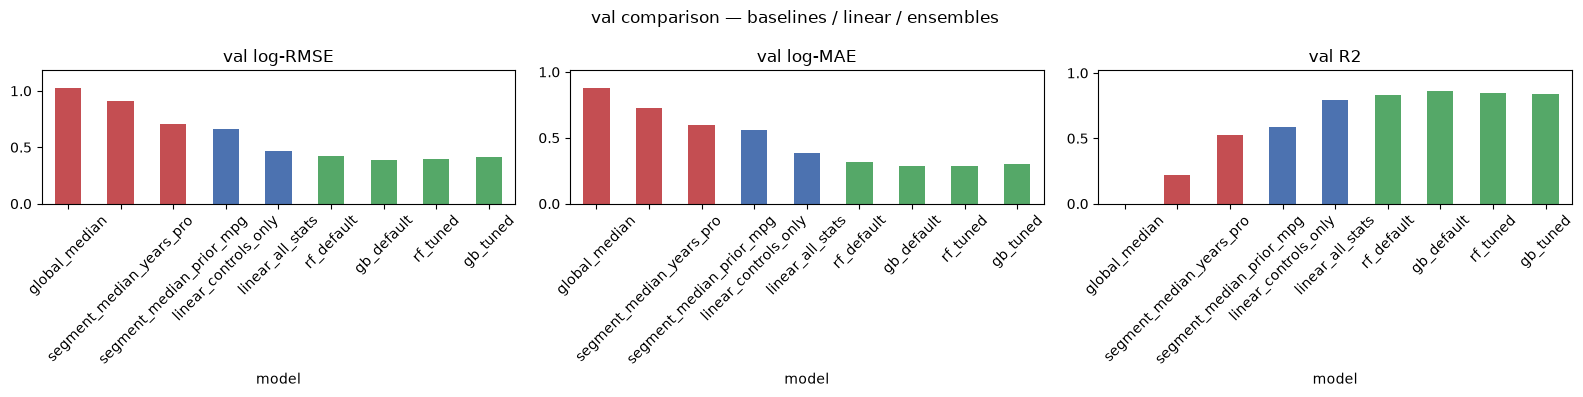

In [8]:
if RESULTS_CSV.exists():
    prev = pd.read_csv(RESULTS_CSV)
else:
    prev = pd.DataFrame(columns=res_new.columns)
res = pd.concat([prev, res_new], ignore_index=True)
res = res.drop_duplicates(subset=["model", "split"], keep="last")
res.to_csv(RESULTS_CSV, index=False)
print("wrote", RESULTS_CSV, res.shape)

order = ["global_median", "segment_median_years_pro", "segment_median_prior_mpg",
         "linear_controls_only", "linear_elasticnet_selected", "linear_pruned", "linear_all_stats",
         "rf_default", "gb_default", "rf_tuned", "gb_tuned"]
order = [m for m in order if m in set(res["model"])]
val = res[res["split"] == "val"].set_index("model").loc[order]
print("\nval metrics (all models):")
print(val[["rmse", "mae", "r2", "rmse_dollars", "mae_dollars"]].round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in (
    (axes[0], "rmse", "val log-RMSE"),
    (axes[1], "mae", "val log-MAE"),
    (axes[2], "r2", "val R2"),
):
    colors = ["#55A868" if m.startswith("rf") or m.startswith("gb") else
              ("#4C72B0" if m.startswith("linear") else "#C44E52") for m in order]
    val[col].plot.bar(ax=ax, color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    if col == "r2":
        ax.set_ylim(0, 1.02)
    else:
        ax.set_ylim(0, val[col].max() * 1.15)
fig.suptitle("val comparison — baselines / linear / ensembles")
fig.tight_layout()
plt.show()

## 7. Feature importance & the context questions

- **Permutation importance** on `val` (more trustworthy than impurity-based MDI for correlated
  features) for the best tuned model.
- **Partial dependence** for the two signing-environment questions: `team_market_size_ord`
  (does a big market pay more?) and `team_nrtg` (does a good team pay *less*?). If the trees
  agree with the linear model — flat market PDP, downward-sloping team-quality PDP — the linear
  read-outs are corroborated by a nonlinear model.

best tuned model on val: rf_tuned



top 12 permutation importances (val):
            feature    imp
         recent3_ws 0.1219
          career_ws 0.0921
          prior_ppg 0.0782
              years 0.0685
          prior_mpg 0.0654
       career_games 0.0274
   max_tier_aav_pct 0.0229
           prior_ws 0.0185
     age_at_signing 0.0130
          prior_tov 0.0124
outstanding_options 0.0107
         career_mpg 0.0086


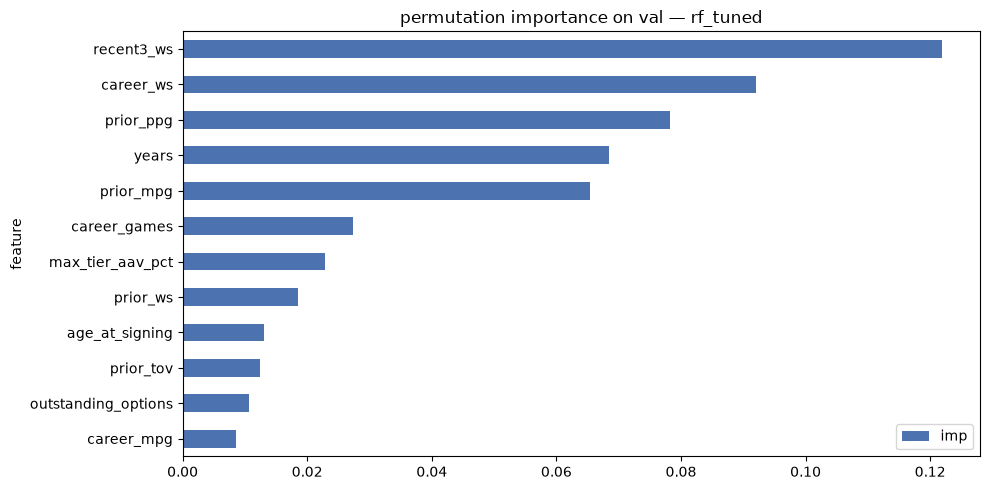

In [9]:
best_model_name = "gb_tuned" if val.loc["gb_tuned", "rmse"] <= val.loc["rf_tuned", "rmse"] else "rf_tuned"
best_model = gb_search if best_model_name == "gb_tuned" else rf_search
print("best tuned model on val:", best_model_name)

X_val = prep.loc[masks["val"], FEATS]
y_val = y[masks["val"]]
pi = permutation_importance(best_model, X_val, y_val, n_repeats=20, random_state=0, n_jobs=-1)
imp = pd.DataFrame({"feature": FEATS, "imp": pi["importances_mean"].round(4)})
imp = imp.reindex(imp["imp"].abs().sort_values(ascending=False).index)
print("\ntop 12 permutation importances (val):")
print(imp.head(12).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
imp.head(12).sort_values("imp").plot.barh(x="feature", y="imp", ax=ax, color="#4C72B0")
ax.set_title(f"permutation importance on val — {best_model_name}")
fig.tight_layout()
plt.show()

### 7b. Box-score stats — do the trees use them?

The 5 prior-season box stats (`prior_ast`, `prior_trb`, `prior_blk`, `prior_stl`, `prior_tov`)
entered the canonical feature set via the MODEL 02 selection. Trees interact natively, so if
position-specialized production matters for pay these should show up in permutation importance on
`val` — and if they *don't*, the position-normalized composites (PER/BPM/VORP/WS) already carried
that information. Reference point: pre-experiment `rf_tuned` val RMSE ≈ 0.3989.

In [10]:
box_stats = ["prior_ast", "prior_trb", "prior_blk", "prior_stl", "prior_tov"]
present = [b for b in box_stats if b in FEATS]
print("box stats present in the tree feature set:", present)
sub = imp[imp["feature"].isin(present)]
print("\npermutation importance of box stats on val:")
print(sub.to_string(index=False) if len(sub) else "(none of the box stats survived into FEATS)")
print("\nrf_tuned val RMSE (post-experiment):", val.loc["rf_tuned", "rmse"])

box stats present in the tree feature set: ['prior_ast', 'prior_trb', 'prior_blk', 'prior_stl', 'prior_tov']

permutation importance of box stats on val:
  feature     imp
prior_tov  0.0124
prior_ast  0.0013
prior_blk -0.0009
prior_trb  0.0007
prior_stl  0.0003

rf_tuned val RMSE (post-experiment): 0.3989


### Verdict: raw box-score stats add nothing for trees either

All five raw box-score stats survived selection into the canonical set (24 chosen stats). On val their permutation importances are near zero (prior_tov 0.017, then ast/trb/stl/blk at <=0.001) and rf_tuned val RMSE is 0.4099 — **worse** than the 0.3989 pre-box-score baseline.

Basketball interpretation: trees can split on interactions natively, so they are the most permissive test. Adding raw ast/trb/blk/stl/tov still doesn't help — the advanced composites already absorb position-specific production, and the extra raw stats are noise. The market prices total on-court value; PER/BPM/VORP/WS are sufficient proxies for it.

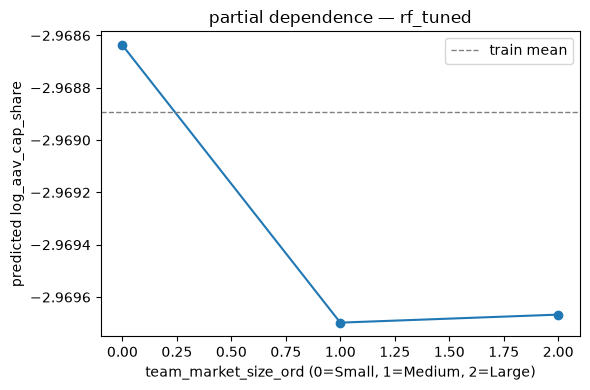

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
pd_part = partial_dependence(best_model, X_train.astype(float), ["team_market_size_ord"],
                             kind="average", grid_resolution=10)
ax.plot(pd_part["grid_values"][0], pd_part["average"][0], marker="o")
ax.axhline(y_train.mean(), color="grey", ls="--", lw=1, label="train mean")
ax.set_xlabel("team_market_size_ord (0=Small, 1=Medium, 2=Large)")
ax.set_ylabel("predicted log_aav_cap_share")
ax.set_title(f"partial dependence — {best_model_name}")
ax.legend()
fig.tight_layout()
plt.show()

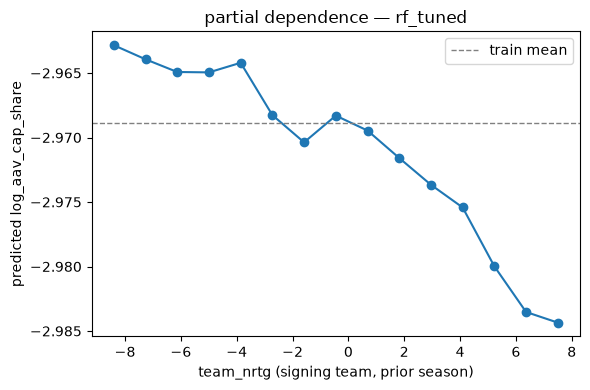

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
pd_part = partial_dependence(best_model, X_train.astype(float), ["team_nrtg"],
                             kind="average", grid_resolution=15)
ax.plot(pd_part["grid_values"][0], pd_part["average"][0], marker="o")
ax.axhline(y_train.mean(), color="grey", ls="--", lw=1, label="train mean")
ax.set_xlabel("team_nrtg (signing team, prior season)")
ax.set_ylabel("predicted log_aav_cap_share")
ax.set_title(f"partial dependence — {best_model_name}")
ax.legend()
fig.tight_layout()
plt.show()

## 8. Predictions

Same schema as `predictions_baselines.csv` / `predictions_linear.csv`, with one column per
ensemble model (default + tuned, RF + GB).

In [13]:
preds = pd.DataFrame({
    "player_id": prep["player_id"],
    "player_name": prep["player_name"],
    "split": prep["split"],
    "log_aav_cap_share": y,
    "rf_default": rf_def_pred,
    "gb_default": gb_def_pred,
    "rf_tuned": rf_tuned_pred,
    "gb_tuned": gb_tuned_pred,
})
preds.to_csv(PRED_CSV, index=False)
print("wrote", PRED_CSV, preds.shape)

wrote ../data/model/predictions_ensemble.csv (1364, 8)


## 9. Takeaways

- **Walk-forward tuning**: best hyperparameters were chosen purely on one-year-ahead folds inside
  the train window; `val`/`test` never influenced a decision. The fold-RMSE table shows how much
  tuning helped over defaults and whether the trees clear the linear reference under the same
  protocol.
- **Model ranking**: ensembles vs the tuned linear model on `val` decides the final story
  (baseline → linear → tree).
- **Context questions**: flat partial dependence on `team_market_size_ord` (markets do not pay
  more) and a downward-sloping `team_nrtg` dependence (good teams pay less) corroborate the
  linear read-outs once quality is controlled.